### import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import nltk
from nltk.corpus import stopwords
import re

nltk.download("stopwords")
STOPWORDS = set(stopwords.words("english"))

pd.set_option("display.max_columns", None)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Plotting aesthetics
sns.set(style='whitegrid')

### Load Dataset

In [4]:
# Change path if your CSV is elsewhere
DATA_PATH = r"C:\Users\Administrator\Downloads\challenge-week1\challenge-week1\data\raw_analyst_ratings.csv"
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

# Preview data
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


### Descriptive Statistics – Headline Length

In [6]:
# Headline Length
# -------------------------------
df['headline'] = df['headline'].fillna('').astype(str)
df['headline_len'] = df['headline'].str.len()

# Show basic statistics
df['headline_len'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

### Plot Headline Length Distribution

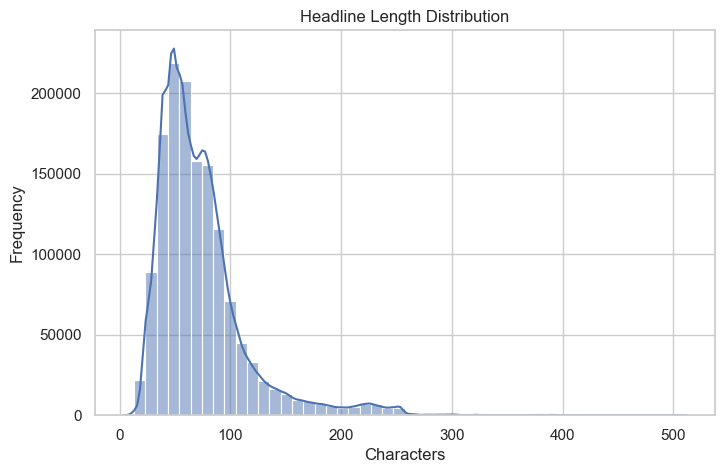

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['headline_len'], bins=50, kde=True)
plt.title('Headline Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.show()


### Publisher Analysis

In [8]:
# -------------------------------
# Publisher Counts
# -------------------------------
df['publisher'] = df['publisher'].fillna('unknown').astype(str)
publisher_counts = df['publisher'].value_counts()
publisher_counts.head(20)


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

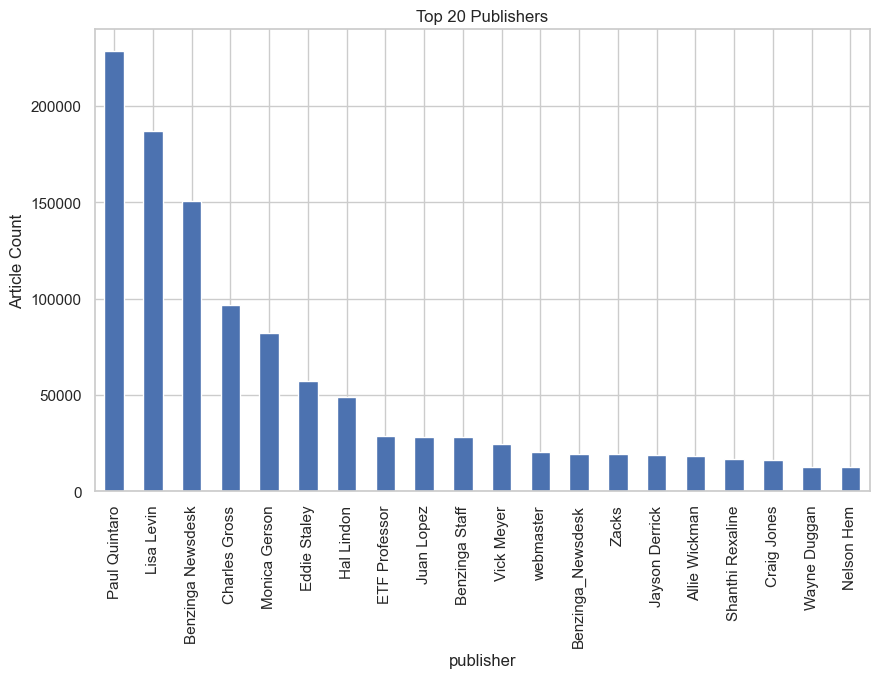

In [9]:
# Plot top 20 publishers
plt.figure(figsize=(10,6))
publisher_counts.head(20).plot(kind='bar')
plt.xticks(rotation=90)
plt.title('Top 20 Publishers')
plt.ylabel('Article Count')
plt.show()


### Time Series Analysis

In [12]:
# -------------------------------
# Safe Date Parsing and Timezone Handling
# -------------------------------

# Parse dates, infer format, coerce errors
df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True, errors='coerce')

# Drop rows with invalid dates
df = df.dropna(subset=['date'])

# Check if timezone is already set
if df['date'].dt.tz is None or df['date'].dt.tz is pd.NaT:
    # Localize naive datetimes to UTC
    df['date'] = df['date'].dt.tz_localize('UTC')
else:
    # Convert tz-aware datetimes to UTC
    df['date'] = df['date'].dt.tz_convert('UTC')

# Preview
df['date'].head()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_4508\849744425.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True, errors='coerce')


0   2020-06-05 14:30:54+00:00
1   2020-06-03 14:45:20+00:00
2   2020-05-26 08:30:07+00:00
3   2020-05-22 16:45:06+00:00
4   2020-05-22 15:38:59+00:00
Name: date, dtype: datetime64[ns, UTC]

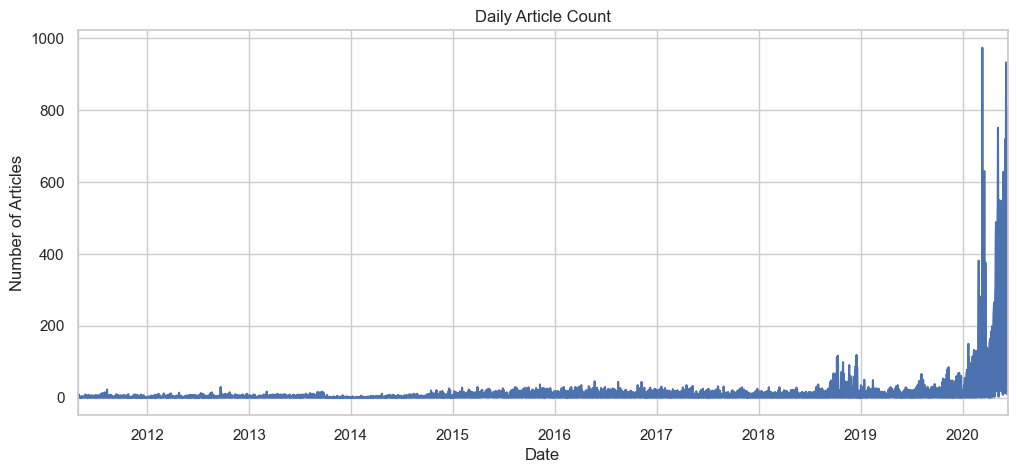

In [13]:
# Daily article count
ts_daily = df.set_index('date').resample('D').size()

plt.figure(figsize=(12,5))
ts_daily.plot()
plt.title('Daily Article Count')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.show()


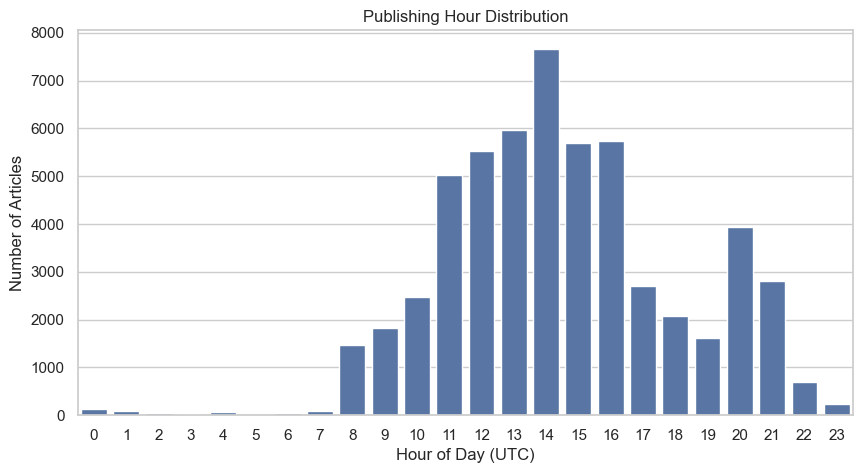

In [14]:
# Hourly publishing pattern
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=df, order=range(24))
plt.title('Publishing Hour Distribution')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Number of Articles')
plt.show()


### Text Cleaning for Topic Modeling

In [15]:
# -------------------------------
# Clean Headline Text
# -------------------------------
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\\S+|www\\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)     # keep alphanumeric
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

df['clean_headline'] = df['headline'].apply(clean_text)
df[['headline','clean_headline']].head()


,headline,clean_headline
0,Stocks That Hit 52-Week Highs On Friday,stocks hit week highs friday
1,Stocks That Hit 52-Week Highs On Wednesday,stocks hit week highs wednesday
2,71 Biggest Movers From Friday,biggest movers friday
3,46 Stocks Moving In Friday's Mid-Day Session,stocks moving friday mid day session
4,B of A Securities Maintains Neutral on Agilent...,securities maintains neutral agilent technolog...


### Topic Modeling (TF-IDF + NMF)

In [16]:
# -------------------------------
# TF-IDF Vectorization
# -------------------------------
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
X = vectorizer.fit_transform(df['clean_headline'])


In [17]:
# -------------------------------
# NMF Topic Modeling
# -------------------------------
n_topics = 6
nmf = NMF(n_components=n_topics, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_
feature_names = vectorizer.get_feature_names_out()

# Display top words per topic
for topic_idx, topic in enumerate(H):
    top_words = [feature_names[i] for i in topic.argsort()[:-15-1:-1]]
    print(f'Topic {topic_idx}: {", ".join(top_words)}')


Topic 0: hit, week, stocks, lows, thursday, highs, friday, wednesday, monday, tuesday, hitting, watch, morning, near, ahead
Topic 1: movers, biggest, yesterday, friday, gainers, changes, day, 108, volume, mid, losers, 102, benzinga, 111, morning
Topic 2: moving, session, stocks, day, mid, pre, market, wednesday, tuesday, monday, friday, thursday, services, update, shares
Topic 3: target, price, maintains, raises, lowers, buy, neutral, morgan, overweight, downgrades, outperform, upgrades, stanley, weight, equal
Topic 4: eps, estimate, sales, yoy, est, beats, beat, miss, reports, adj, misses, shares, trading, financial, bancorp
Topic 5: new, set, low, yesterday, week, stocks, 2018, october, dec, nov, september, tues, trading, high, fri


### Publisher vs Topic Analysis

In [18]:
# Assign dominant topic to each article
topic_labels = np.argmax(W, axis=1)
df['topic'] = topic_labels

# Top publishers per topic
for t in range(n_topics):
    print(f"\n--- Topic {t} Top Publishers ---")
    top_publishers = df[df['topic']==t]['publisher'].value_counts().head(10)
    print(top_publishers)



--- Topic 0 Top Publishers ---
publisher
Lisa Levin           4945
Benzinga Insights     989
Benzinga Newsdesk     199
Shanthi Rexaline      139
Nelson Hem             96
ETF Professor          65
Charles Gross          34
Wayne Duggan           21
Monica Gerson          20
Matthew McCall         15
Name: count, dtype: int64

--- Topic 1 Top Publishers ---
publisher
Lisa Levin           2078
Benzinga Newsdesk      20
Monica Gerson          14
Javier Hasse           14
John Seward            12
Charles Gross          11
ETF Professor           8
Matthew McCall          6
Wayne Duggan            4
Andrew Efimoff          4
Name: count, dtype: int64

--- Topic 2 Top Publishers ---
publisher
Lisa Levin           3493
Benzinga Insights     813
Benzinga Newsdesk     758
ETF Professor         268
Benzinga Newsdesk     250
Paul Quintaro         216
Monica Gerson         201
Charles Gross         191
Wayne Duggan          122
Shanthi Rexaline       69
Name: count, dtype: int64

--- Topic 3 Top

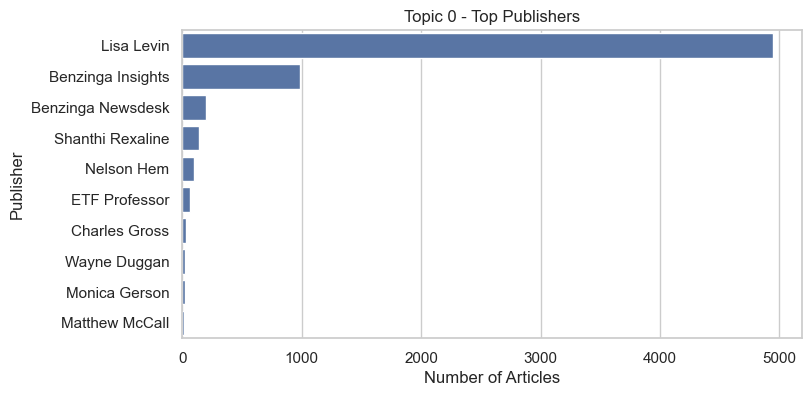

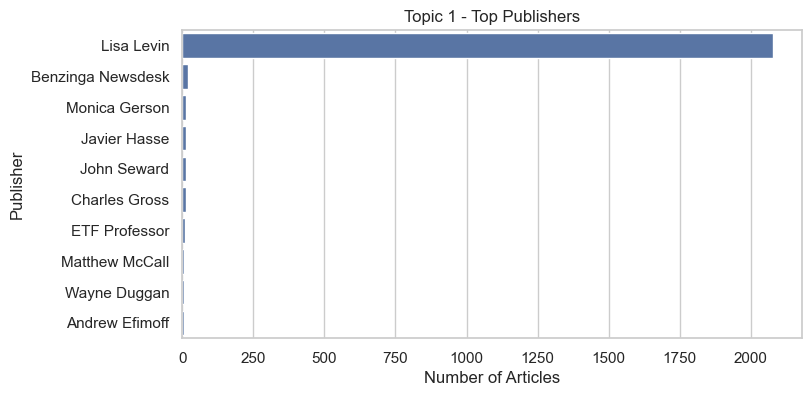

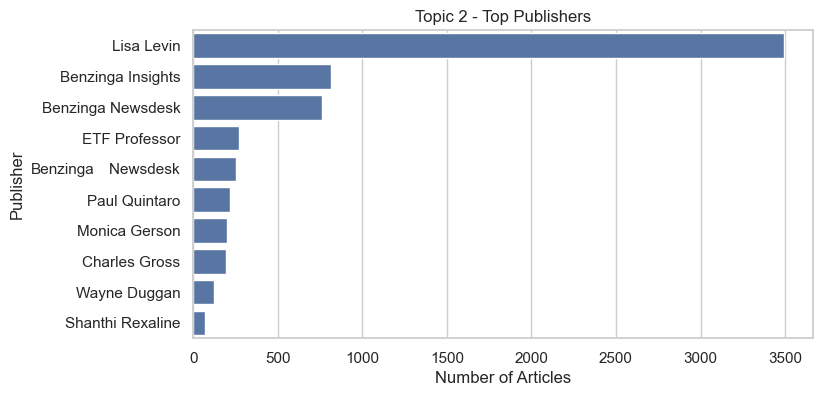

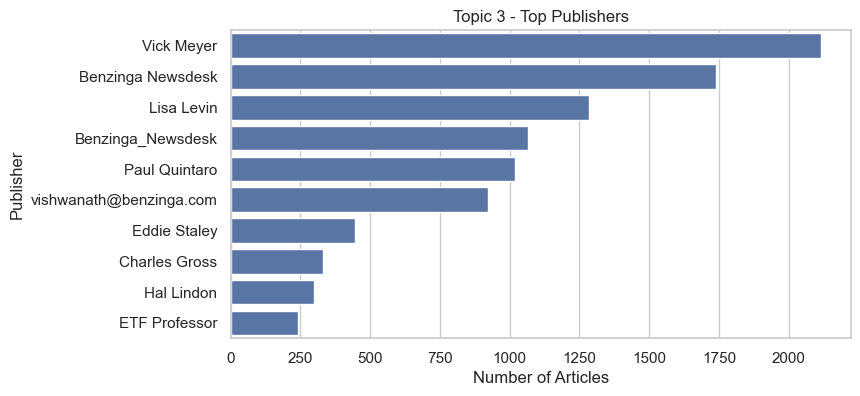

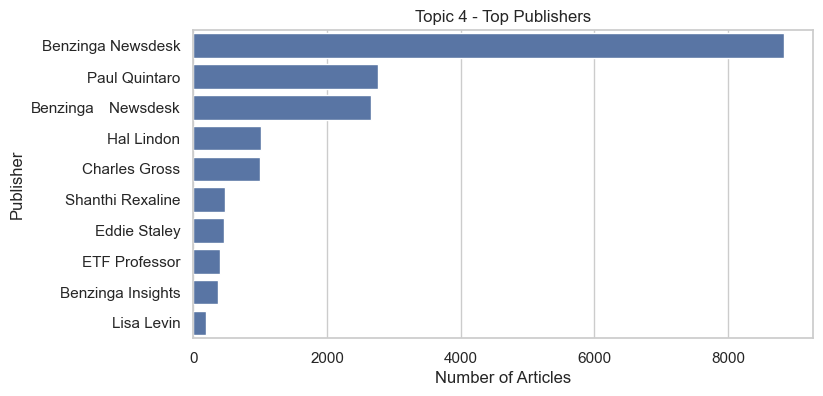

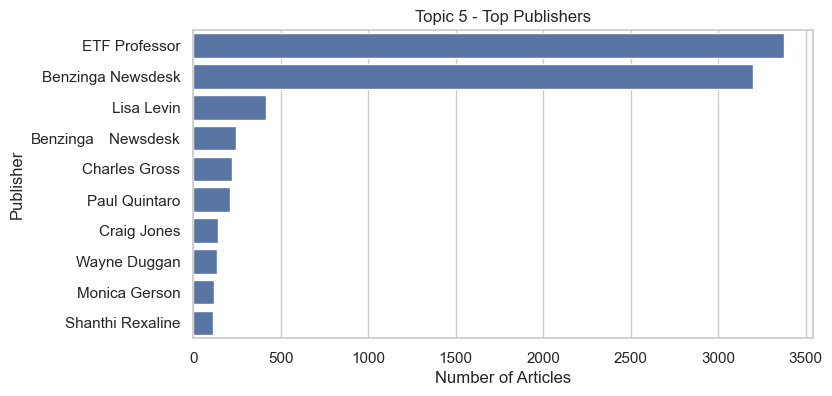

In [19]:
# Bar plot of top publishers for each topic
for t in range(n_topics):
    plt.figure(figsize=(8,4))
    top_publishers = df[df['topic']==t]['publisher'].value_counts().head(10)
    sns.barplot(x=top_publishers.values, y=top_publishers.index)
    plt.title(f'Topic {t} - Top Publishers')
    plt.xlabel('Number of Articles')
    plt.ylabel('Publisher')
    plt.show()


### Spike Detection in Daily Article Counts

In [20]:
# Calculate daily mean and standard deviation
daily_mean = ts_daily.mean()
daily_std = ts_daily.std()

# Define spikes: days with articles > mean + 2*std
spike_threshold = daily_mean + 2*daily_std
spike_days = ts_daily[ts_daily > spike_threshold]

print("Spike Days (High Article Count):")
print(spike_days)


Spike Days (High Article Count):
date
2020-01-22 00:00:00+00:00    150
2020-02-27 00:00:00+00:00    275
2020-02-28 00:00:00+00:00    381
2020-03-05 00:00:00+00:00    138
2020-03-06 00:00:00+00:00    281
                            ... 
2020-06-05 00:00:00+00:00    932
2020-06-08 00:00:00+00:00    765
2020-06-09 00:00:00+00:00    803
2020-06-10 00:00:00+00:00    807
2020-06-11 00:00:00+00:00    544
Length: 61, dtype: int64


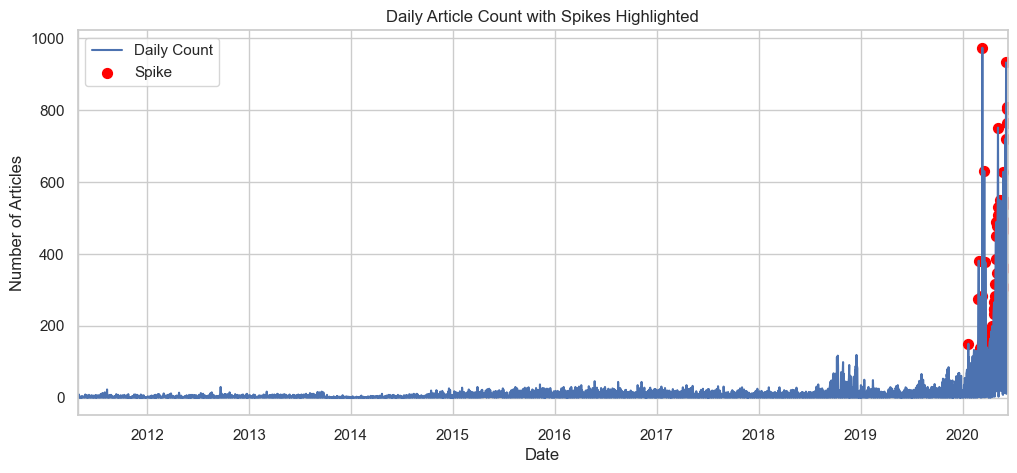

In [21]:
plt.figure(figsize=(12,5))
ts_daily.plot(label='Daily Count')
plt.scatter(spike_days.index, spike_days.values, color='red', label='Spike', s=50)
plt.title('Daily Article Count with Spikes Highlighted')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.legend()
plt.show()


### Top Keywords per Topic

In [22]:
for t in range(n_topics):
    top_words = [feature_names[i] for i in H[t].argsort()[:-15-1:-1]]
    print(f"Topic {t} Keywords: {', '.join(top_words)}")


Topic 0 Keywords: hit, week, stocks, lows, thursday, highs, friday, wednesday, monday, tuesday, hitting, watch, morning, near, ahead
Topic 1 Keywords: movers, biggest, yesterday, friday, gainers, changes, day, 108, volume, mid, losers, 102, benzinga, 111, morning
Topic 2 Keywords: moving, session, stocks, day, mid, pre, market, wednesday, tuesday, monday, friday, thursday, services, update, shares
Topic 3 Keywords: target, price, maintains, raises, lowers, buy, neutral, morgan, overweight, downgrades, outperform, upgrades, stanley, weight, equal
Topic 4 Keywords: eps, estimate, sales, yoy, est, beats, beat, miss, reports, adj, misses, shares, trading, financial, bancorp
Topic 5 Keywords: new, set, low, yesterday, week, stocks, 2018, october, dec, nov, september, tues, trading, high, fri
